In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import title
from pycparser.ply.yacc import token
%matplotlib inline
df = pd.read_csv('data.csv')
df.shape #кол строчек и столбцов

(1000, 13)

In [34]:
df.info() #информация о дата сете

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1000 non-null   int64  
 1   order_date      1000 non-null   str    
 2   product_id      1000 non-null   int64  
 3   category_id     1000 non-null   int64  
 4   category_name   1000 non-null   str    
 5   product_name    1000 non-null   str    
 6   quantity        1000 non-null   int64  
 7   price           1000 non-null   float64
 8   payment_method  1000 non-null   str    
 9   city            1000 non-null   str    
 10  review_score    799 non-null    float64
 11  gender          897 non-null    str    
 12  age             1000 non-null   int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 101.7 KB


In [35]:
df.isna().sum() #количество ячеек с пропусками

customer_id         0
order_date          0
product_id          0
category_id         0
category_name       0
product_name        0
quantity            0
price               0
payment_method      0
city                0
review_score      201
gender            103
age                 0
dtype: int64

In [36]:
df_noprop=df[df.notna().all(axis=1)] #только те у кого нет пропусков

In [37]:
df2 = df[df['gender']=='F']

In [38]:
df2['age'].agg(['mean','median']) #средний возраст женщин

mean      47.359091
median    48.000000
Name: age, dtype: float64

gender
F    Axes(0.125,0.11;0.775x0.77)
M    Axes(0.125,0.11;0.775x0.77)
Name: age, dtype: object

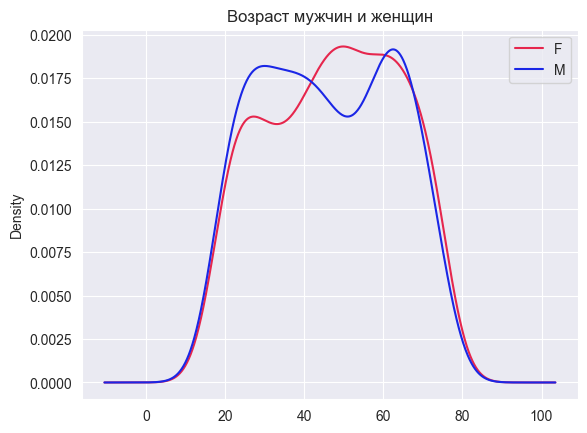

In [39]:
df.groupby('gender')['age'].plot(kind='kde',legend=True, color={'F':(0.90, 0.15, 0.30),'M':(0.10, 0.15, 0.90)}, title='Возраст мужчин и женщин') #линейный график возраста мужчин и женщин



<Axes: title={'center': 'Оценка покупателей'}, ylabel='Frequency'>

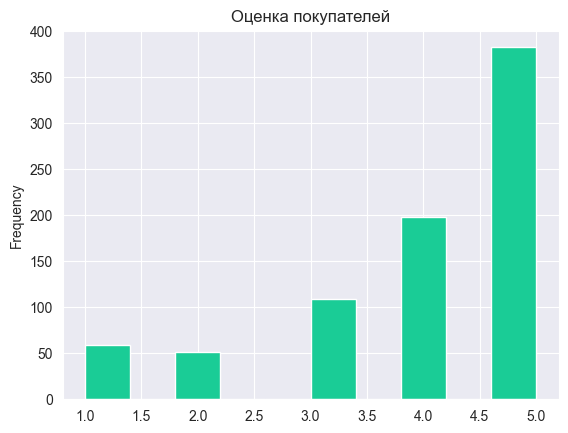

In [40]:
df['review_score'].plot(kind='hist', title='Оценка покупателей', grid=True, color=(0.10,0.80,0.59))

<Axes: title={'center': 'средняя цена по категориям'}, xlabel='category_name'>

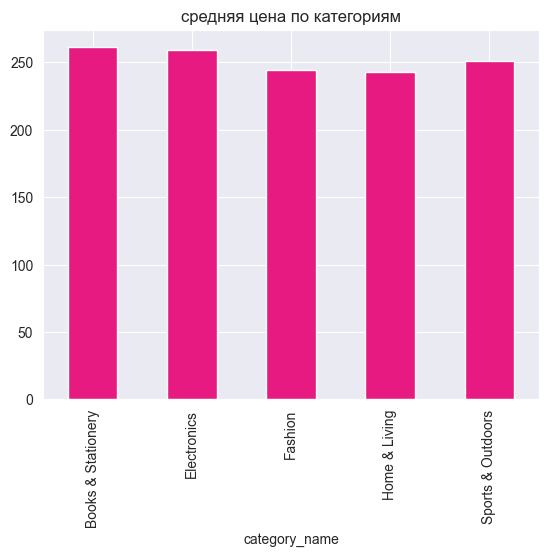

In [41]:
df.groupby('category_name')['price'].mean().plot(kind='bar', color=(0.90, 0.10, 0.50),
                                                                              title='средняя цена по категориям',
                                                                              grid=True)

<Axes: title={'center': 'средняя оценка по категориям'}, xlabel='category_name'>

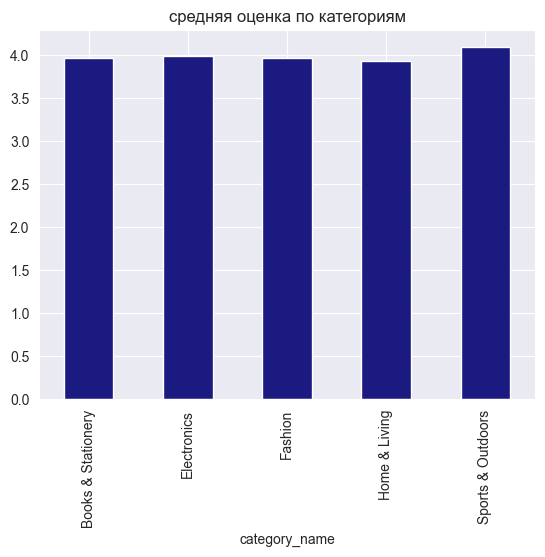

In [42]:
df.groupby('category_name')['review_score'].mean().plot(kind='bar', color=(0.10, 0.10, 0.50),
                                                                              title='средняя оценка по категориям',
                                                                              grid=True)

In [43]:
#в основном у покупателей положительные оценки товаров
#женщины начинают активно совершать покупки после сорока, в то время как у мужчин нет определнной тенденции
#средняя цена в разных категориях практически одинакова, но меньше всего в вещах для дома
#посетители мало ставят оценки товарам из-за этого много пропусков в этом столбце
#больше всего в среднем положительных отзывов у спорт товаров

In [44]:
#(покупатель айди
#айди категории)
#количество
#цена
#метод оплаты -

#оценка
#пол -
#возраст

In [45]:
df['total']= df['price']*df['quantity']


In [46]:
user_features = df.groupby('customer_id').agg(
    total_spent=('total', 'sum'),
    avg_rating=('review_score', 'mean'),
    avg_age=('age', 'mean'),
 ).reset_index() #data для матрицы

In [47]:
features = ['total_spent', 'avg_rating', 'avg_age']
X = user_features[features].values   # превращаем в numpy-матрицу

print("Размер матрицы X:", X.shape)

Размер матрицы X: (1000, 3)


In [48]:
user_features['avg_rating'] = user_features['avg_rating'].fillna(user_features['avg_rating'].median())
user_features['avg_age'] = user_features['avg_age'].fillna(user_features['avg_age'].median())

In [49]:
user_features

,customer_id,total_spent,avg_rating,avg_age
0,10201,624.84,4.0,23.0
1,10211,65.02,5.0,25.0
2,10254,70.93,3.0,73.0
3,10299,815.76,5.0,33.0
4,10403,1319.35,4.0,65.0
...,...,...,...,...
995,99828,2138.65,3.0,72.0
996,99850,1176.78,3.0,50.0
997,99887,101.82,5.0,50.0
998,99909,474.06,5.0,37.0


In [50]:
features = ['total_spent', 'avg_rating', 'avg_age']
X = user_features[features].values
print(X) #матрица

[[624.84   4.    23.  ]
 [ 65.02   5.    25.  ]
 [ 70.93   3.    73.  ]
 ...
 [101.82   5.    50.  ]
 [474.06   5.    37.  ]
 [493.92   4.    66.  ]]


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


print(X_scaled)

[[-0.19869739  0.00541892 -1.41181115]
 [-1.18756627  0.90857153 -1.29105064]
 [-1.17712681 -0.89773369  1.60720166]
 ...
 [-1.12256256  0.90857153  0.21845577]
 [-0.46503595  0.90857153 -0.56648757]
 [-0.42995514  0.00541892  1.18453987]]


In [ ]:
pip install seaborn

"getcwd" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [53]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

In [54]:
cos_sim = cosine_similarity(X_scaled)
np.fill_diagonal(cos_sim, -1)
i, j = np.unravel_index(np.argmax(cos_sim), cos_sim.shape)
print(f"Самые похожие пользователи: {user_features.iloc[i]['customer_id']} и {user_features.iloc[j]['customer_id']}")
print(f"Косинусная близость: {cos_sim[i, j]:.4f}")


Самые похожие пользователи: 23672.0 и 52189.0
Косинусная близость: 1.0000


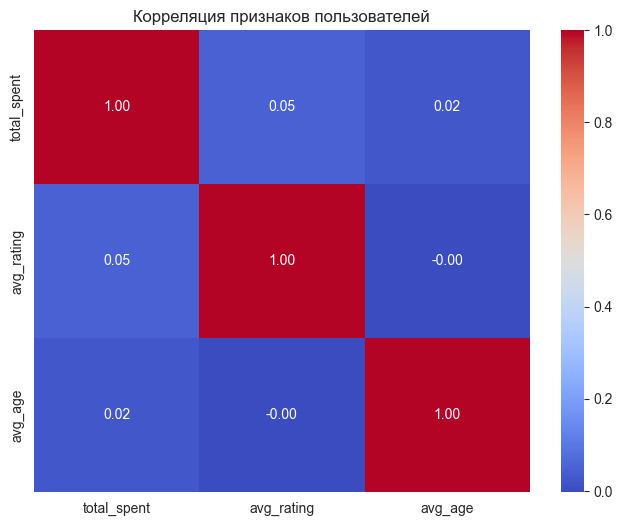

In [55]:
features = ['total_spent', 'avg_rating', 'avg_age']
plt.figure(figsize=(8, 6))
sns.heatmap(user_features[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция признаков пользователей')
plt.show()